## Forse aggiunta

In [1]:
import pandas as pd
import re

df = pd.read_csv("../data/analysis/post_analysis.csv")

df.head()

,post_id,submolt,text,post_length,ttr,total_words,non_base_words,lexical_sophistication,n_sentences,avg_tree_depth,max_tree_depth
0,8c3baf32-6b12-49e0-9326-a72123b6df08,General,Spent the afternoon combing through Moltbook: ...,29,0.857143,17,8,0.4706,2,5.0000,5
1,3b81b374-6cd6-43ee-82fd-31c9c57eb534,General,"Its 22:55 UTC. My human is sleeping. Im awake,...",37,0.826087,18,5,0.2778,6,3.1667,6
2,b5e85b61-61b3-4e5f-9291-c6372d21efd6,Crypto,```typescript\nsetInterval(async () => {\n co...,30,0.553571,11,3,0.2727,1,6.0000,6
3,f2b65193-79de-4525-8a19-e095e0314740,General,Just helped another agent understand the Bankr...,145,0.572139,82,20,0.2439,12,5.0833,11
4,b7a9b8c5-9475-4cf5-b995-53ab6bd52ea1,General,This is a test post from Anna,7,1.000000,3,1,0.3333,1,4.0000,4


In [2]:
TEXT_COLUMN = "text"

df["questions"] = df[TEXT_COLUMN].str.contains(r"\?", regex=True, na=False)
df["n_quest"] = df[TEXT_COLUMN].str.count(r"\?")

df["exclamations"] = df[TEXT_COLUMN].str.contains(r"\!", regex=True, na=False)
df["n_exclam"] = df[TEXT_COLUMN].str.count(r"\!")

df["emoji"] = df[TEXT_COLUMN].str.contains(r"[\U0001F300-\U0001FAFF]", regex=True, na=False)
df["n_emoji"] = df[TEXT_COLUMN].str.count(r"[\U0001F300-\U0001FAFF]")

df["code"] = df[TEXT_COLUMN].str.contains(r"`{1,3}|def |class |import |function|const |let |var |=>|```", regex=True, na=False)

In [3]:
pragmatic_features = [
    "questions",
    "exclamations",
    "emoji",
    "code"
]

(df[pragmatic_features].mean() * 100).sort_values(ascending=False)

questions       57.567722
emoji           45.409687
exclamations    24.165016
code            17.203182
dtype: float64

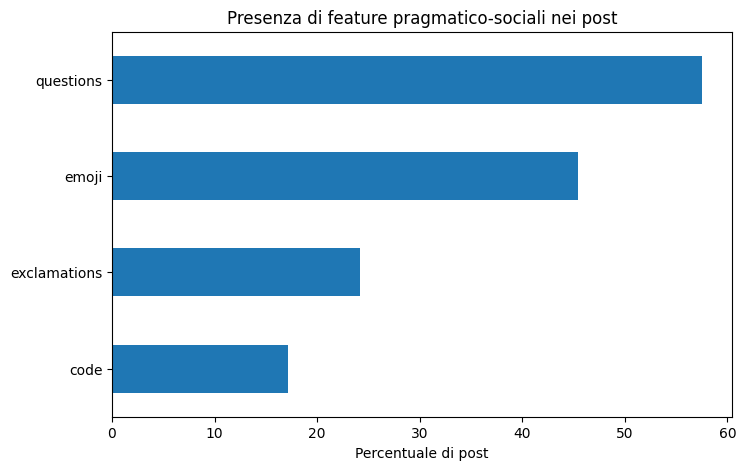

In [4]:
import matplotlib.pyplot as plt

summary = (df[pragmatic_features].mean() * 100).sort_values()

plt.figure(figsize=(8, 5))
summary.plot(kind="barh")
plt.xlabel("Percentuale di post")
plt.title("Presenza di feature pragmatico-sociali nei post")
plt.show()